<a href="https://colab.research.google.com/github/ThanhTruc297PRJ/TH_DLN/blob/main/Buoi3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cài đặt CNN

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

In [4]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [5]:
num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


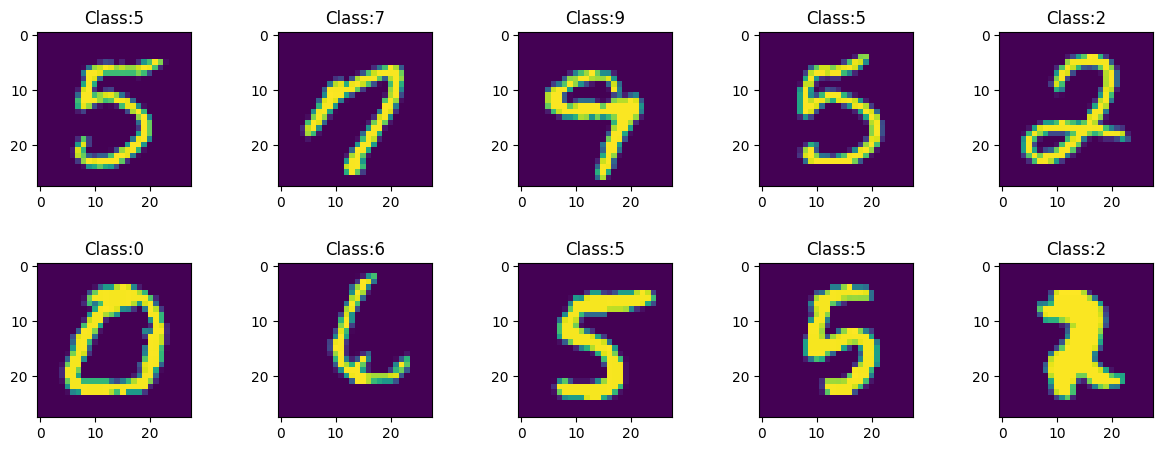

In [6]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:' + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [7]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


2. xây dựng mô hình CNN


In [8]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation = 'softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - accuracy: 0.8322 - loss: 0.5901 - val_accuracy: 0.9355 - val_loss: 0.2139
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.9574 - loss: 0.1450 - val_accuracy: 0.9610 - val_loss: 0.1286
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - accuracy: 0.9721 - loss: 0.0958 - val_accuracy: 0.9620 - val_loss: 0.1129
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 23s 116ms/step - accuracy: 0.9774 - loss: 0.0744 - val_accuracy: 0.9695 - val_loss: 0.0930
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.9812 - loss: 0.0599 - val_accuracy: 0.9750 - val_loss: 0.0781
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.9837 - loss: 0.0542 - val_accuracy: 0.9765 - val_loss: 0.0780
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - accuracy: 0.9856 - loss: 0.0462 - val_accuracy: 0.9790 - val_loss: 0.0695
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - accuracy: 0.9873 - loss: 0.037

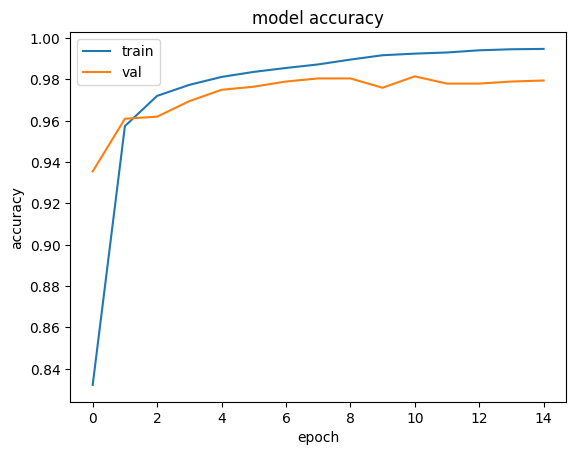

In [10]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

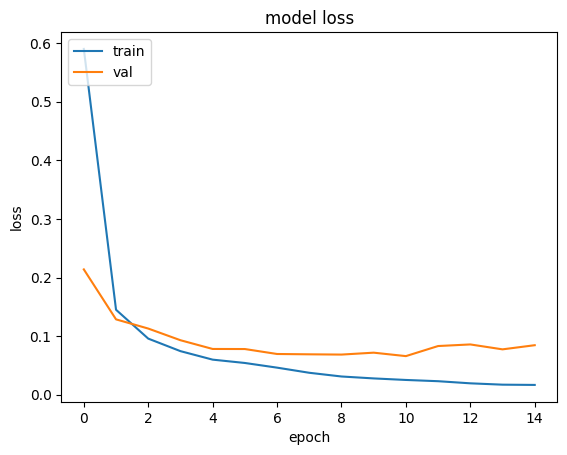

In [11]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [12]:
#đánh giá mô hình
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 8ms/step - accuracy: 0.9830 - loss: 0.0615
Test loss: 0.06146658957004547
Test accuracy: 0.9829983115196228


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
[[6.8748144e-05 5.7910795e-05 9.9986863e-01 3.3734072e-08 7.8741994e-18
  2.0469068e-15 4.6783207e-06 6.2310555e-16 1.3059834e-08 1.9626975e-20]]
2 2


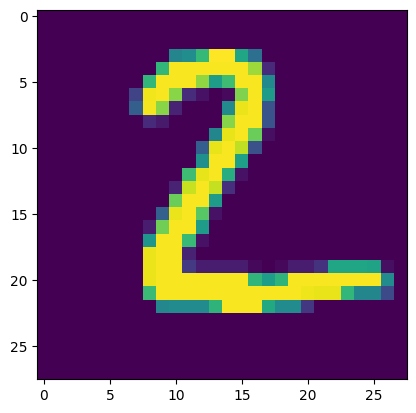

In [13]:
#dự báo nhãn cho ảnh sử dụng CNN
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

In [17]:
#luu tham số mô hình CNN
model.save_weights('model_weights.weights.h5')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
[[5.7139811e-08 9.9995434e-01 1.0104825e-05 3.5713134e-07 2.0678306e-05
  1.3810543e-08 5.4255048e-07 3.9252936e-06 1.0035419e-05 5.0630355e-10]]
1 1


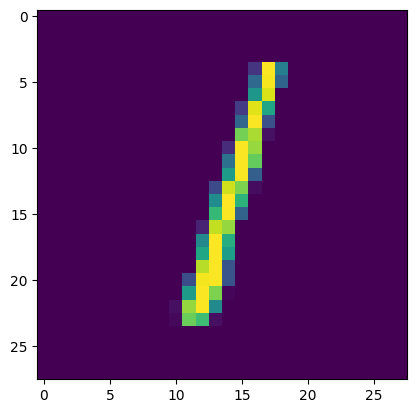

In [19]:
#nạp lại mô hình và tham số
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))

# SỬA TẠI ĐÂY: Bỏ model.add và dùng đúng tên file đã lưu ở bước trước
model.load_weights('model_weights.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()